In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv('/content/student_performance.csv')

In [ ]:
df.head()

,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks,Final_Result
0,1,5.6,76,35,45,82,Pass
1,2,2.5,79,55,36,34,Pass
2,3,5.7,79,77,66,34,Pass
3,4,3.1,81,44,83,40,Pass
4,5,3.6,81,73,40,90,Pass


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      300 non-null    int64  
 1   Study_Hours     300 non-null    float64
 2   Attendance      300 non-null    int64  
 3   Previous_Marks  300 non-null    int64  
 4   Assignments     300 non-null    int64  
 5   Internal_Marks  300 non-null    int64  
 6   Final_Result    300 non-null    object 
dtypes: float64(1), int64(5), object(1)
memory usage: 16.5+ KB


In [ ]:
df.isnull().sum()

,0
Student_ID,0
Study_Hours,0
Attendance,0
Previous_Marks,0
Assignments,0
Internal_Marks,0
Final_Result,0


In [ ]:
label_encoder = LabelEncoder()
df['Final_Result'] = label_encoder.fit_transform(df['Final_Result'])

In [ ]:
X = df[['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignments', 'Internal_Marks']]
y = df['Final_Result']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Load the dataset (redundant if already loaded, but ensures availability)
df = pd.read_csv('/content/student_performance.csv')

# Encode 'Final_Result' (redundant if already encoded, but ensures consistency)
label_encoder = LabelEncoder()
df['Final_Result'] = label_encoder.fit_transform(df['Final_Result'])

# Define X and y
X = df[['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignments', 'Internal_Marks']]
y = df['Final_Result']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the dataset
df = pd.read_csv('/content/student_performance.csv')

# Encode 'Final_Result'
label_encoder = LabelEncoder()
df['Final_Result'] = label_encoder.fit_transform(df['Final_Result'])

# Define X and y
X = df[['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignments', 'Internal_Marks']]
y = df['Final_Result']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Initialize and train Logistic Regression model
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 1.0
[[60]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        60

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
df['Predicted'] = lr_model.predict(X_scaled)

at_risk_students = df[df['Predicted'] == 0]
print(at_risk_students[['Student_ID', 'Study_Hours', 'Attendance']])

Empty DataFrame
Columns: [Student_ID, Study_Hours, Attendance]
Index: []


In [ ]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 1.0
[[60]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        60

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
df['Predicted'] = lr_model.predict(X_scaled)

at_risk_students = df[df['Predicted'] == 0]
print(at_risk_students[['Student_ID', 'Study_Hours', 'Attendance']])

Empty DataFrame
Columns: [Student_ID, Study_Hours, Attendance]
Index: []


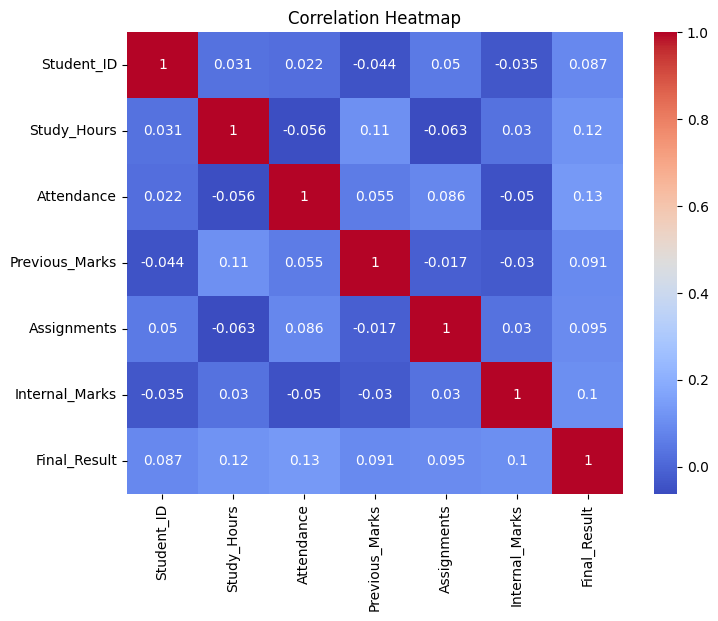

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

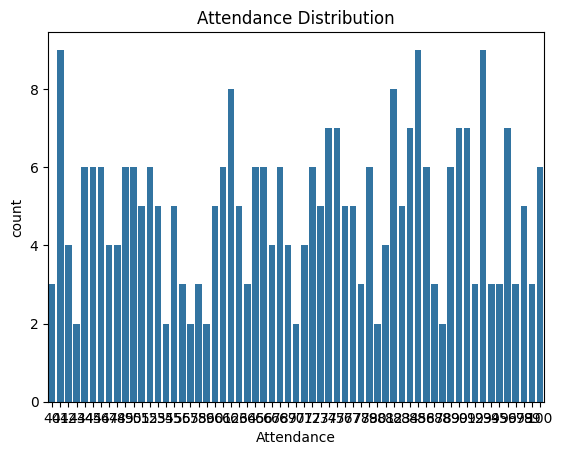

In [ ]:
sns.countplot(x='Attendance', data=df)
plt.title('Attendance Distribution')
plt.show()

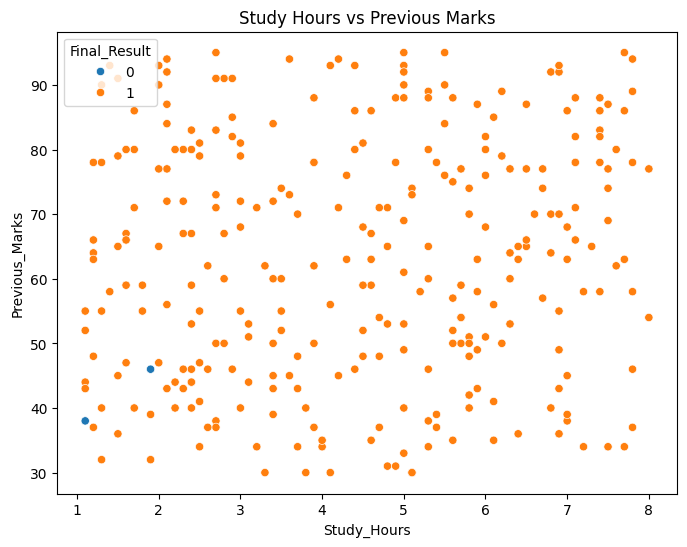

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Study_Hours', y='Previous_Marks', hue='Final_Result', data=df)
plt.title('Study Hours vs Previous Marks')
plt.show()

In [ ]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 1.0
[[60]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        60

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0
[[60]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        60

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print('Naive Bayes Accuracy:', accuracy_score(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 1.0
[[60]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        60

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
svm_model = SVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print('SVM Accuracy:', accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 1.0
[[60]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        60

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
accuracy_results = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'Decision Tree': accuracy_score(y_test, y_pred_dt),
    'Naive Bayes': accuracy_score(y_test, y_pred_nb),
    'SVM': accuracy_score(y_test, y_pred_svm)
}

accuracy_df = pd.DataFrame(list(accuracy_results.items()), columns=['Model', 'Accuracy'])
print(accuracy_df)

                 Model  Accuracy
0  Logistic Regression       1.0
1        Decision Tree       1.0
2          Naive Bayes       1.0
3                  SVM       1.0


In [ ]:
print(df.corr(numeric_only=True)['Final_Result'].sort_values(ascending=False))

Final_Result      1.000000
Attendance        0.134994
Study_Hours       0.118718
Internal_Marks    0.103770
Assignments       0.095267
Previous_Marks    0.091184
Student_ID        0.086557
Predicted              NaN
Name: Final_Result, dtype: float64


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


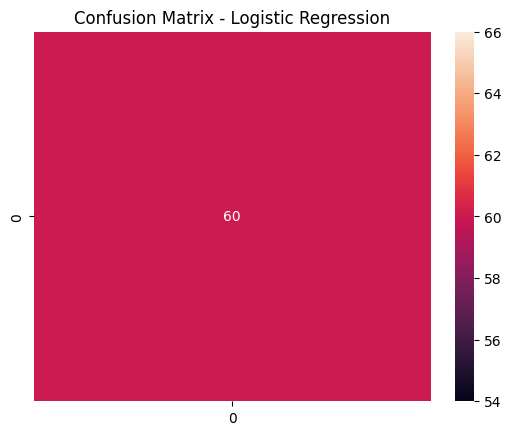

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

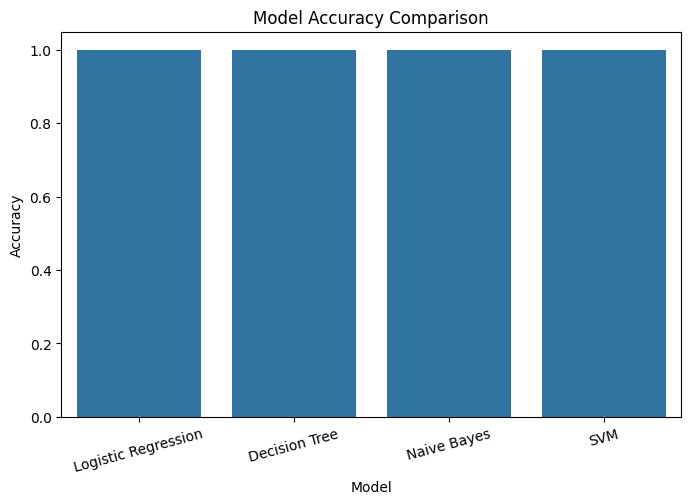

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df)
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=15)
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train and predict for Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Train and predict for Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Train and predict for Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

# Train and predict for SVM
svm_model = SVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Calculate accuracy results
accuracy_results = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'Decision Tree': accuracy_score(y_test, y_pred_dt),
    'Naive Bayes': accuracy_score(y_test, y_pred_nb),
    'SVM': accuracy_score(y_test, y_pred_svm)
}

accuracy_df = pd.DataFrame(list(accuracy_results.items()), columns=['Model', 'Accuracy'])
best_model = accuracy_df.sort_values(by='Accuracy', ascending=False).iloc[0]
print("Best Model:", best_model['Model'])

Best Model: Logistic Regression


In [ ]:
df['Predicted'] = lr_model.predict(X_scaled)

at_risk_students = df[df['Predicted'] == 0]
print(at_risk_students[['Student_ID', 'Study_Hours', 'Attendance']])

Empty DataFrame
Columns: [Student_ID, Study_Hours, Attendance]
Index: []


In [8]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load the dataset (ensuring df is available)
# If you encounter FileNotFoundError, please ensure 'student_performance.csv' is uploaded to /content/ or specify the correct path.
df = pd.read_csv('/content/student_performance.csv')

# Encode 'Final_Result' (ensuring df['Final_Result'] is numeric)
label_encoder = LabelEncoder()
df['Final_Result'] = label_encoder.fit_transform(df['Final_Result'])

# Define X and y (ensuring X is available for scaler.fit_transform)
X = df[['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignments', 'Internal_Marks']]
y = df['Final_Result']

# Scale the features (defining and fitting scaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # X_scaled is needed for training, and fitting scaler

# Split the data (required for training lr_model)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
df['Predicted'] = lr_model.predict(X_scaled)
at_risk = df[df['Predicted'] == 0]
print(at_risk)

Empty DataFrame
Columns: [Student_ID, Study_Hours, Attendance, Previous_Marks, Assignments, Internal_Marks, Final_Result, Predicted]
Index: []


In [ ]:
new_student = [[5, 85, 75, 80, 78]]

new_student_scaled = scaler.transform(new_student)

prediction = lr_model.predict(new_student_scaled)

if prediction[0] == 1:
    print('Predicted Result: Pass')
else:
    print('Predicted Result: Fail')

Predicted Result: Pass


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [15]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load the dataset (ensuring df is available)
df = pd.read_csv('/content/student_performance.csv')

# Encode 'Final_Result' (ensuring df['Final_Result'] is numeric)
label_encoder = LabelEncoder()
df['Final_Result'] = label_encoder.fit_transform(df['Final_Result'])

# Define X and y (ensuring X is available for scaler.fit_transform)
X = df[['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignments', 'Internal_Marks']]
y = df['Final_Result']

# Scale the features (defining and fitting scaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # X_scaled is needed for training, and fitting scaler

# Split the data (required for training lr_model)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Initialize and train Logistic Regression model (ensuring lr_model is available)
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Original input and prediction logic
study = float(input("Enter Study Hours: "))
attendance = float(input("Enter Attendance: "))
marks = float(input("Enter Previous Marks: "))
assign = float(input("Enter Assignments Score: "))
internal = float(input("Enter Internal Marks: "))

# Create input array
new_student = [[study, attendance, marks, assign, internal]]

new_student_scaled = scaler.transform(new_student)

# Predict using trained model
prediction = lr_model.predict(new_student_scaled)

# Convert prediction to readable output
if prediction[0] == 1:
    print("Predicted Result: Pass")

else:
    print("Predicted Result: Fail")

Enter Study Hours: 1
Enter Attendance: 33
Enter Previous Marks: 12
Enter Assignments Score: 21
Enter Internal Marks: 22
Predicted Result: Fail


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
